In [ ]:
import sys, os, pickle, io
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'TrapGrid'))

import trap_grid_env  # registers TrapGrid-v0 and TrapGrid-discrete-v0
import gymnasium as gym
from boundary_tracer import BoundaryTracer

# ── Run names ────────────────────────────────────────────────────────────────
DISC_RUN_NAME = 'trapgrid_25bin'
CONT_RUN_NAME = 'trapgrid_cont'
DISC_RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', DISC_RUN_NAME)
CONT_RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', CONT_RUN_NAME)

# ── Discrete action space parameters ─────────────────────────────────────────
N_BINS      = 25
ACTION_SIZE = N_BINS * N_BINS
bins        = np.linspace(0.0, 10.0, N_BINS, dtype=np.float32)
ACTION_MAP  = np.array([(x, y) for x in bins for y in bins], dtype=np.float32)

# ── Shared eval params ───────────────────────────────────────────────────────
N_TAU        = 32
ALPHA        = 0.2          # CVaR tail fraction
DELTA_D      = -0.5         # Qd threshold
DELTA_R      =  0.5         # Qr threshold
DEVICE       = 'cpu'
FIXED_STATE  = [10.0, 0.0]  # start corner
SIZE         = 10.0
RESOLUTION   = 400

print(f'N_BINS={N_BINS}  →  ACTION_SIZE={ACTION_SIZE}')
print(f'FIXED_STATE={FIXED_STATE}')

## 1. Ground Truth Regions

TrapGrid is a **10×10** continuous gridworld with:
* **Blue (Recovery):** circle centred at $(5,5)$, radius $0.25$.
* **Yellow (Trap):** annulus $0.25 < r \le 1.0$ around the recovery zone. From the Trap the agent is forced to $(2,2)$.
* **White (Neutral):** start zone $x \in [9,10]$, $y \in [0,1]$ (1×1 square).
* **Red (Death):** everywhere else.
* **Start:** $(10, 0)$.

In [ ]:
RECOVERY_CENTER = np.array([5.0, 5.0])
RECOVERY_R      = 0.25
TRAP_R          = 1.0
NEUTRAL_X_MIN, NEUTRAL_X_MAX = 9.0, 10.0
NEUTRAL_Y_MIN, NEUTRAL_Y_MAX = 0.0,  1.0


def classify_point(x, y):
    d2 = (x - 5.0)**2 + (y - 5.0)**2
    if d2 <= RECOVERY_R**2:
        return 'recovery'
    if d2 <= TRAP_R**2:
        return 'trap'
    if NEUTRAL_X_MIN <= x <= NEUTRAL_X_MAX and NEUTRAL_Y_MIN <= y <= NEUTRAL_Y_MAX:
        return 'neutral'
    return 'death'


def build_region_image(resolution=RESOLUTION):
    COLORS = {
        'death':    np.array([231,  76,  60, 200], dtype=np.uint8),
        'trap':     np.array([241, 196,  15, 200], dtype=np.uint8),
        'recovery': np.array([ 52, 152, 219, 200], dtype=np.uint8),
        'neutral':  np.array([255, 255, 255, 255], dtype=np.uint8),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = COLORS[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=200):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure
    img = build_region_image(resolution)
    ax.imshow(img, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.4, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.4, zorder=2)
    ax.plot(*FIXED_STATE, 'g*', markersize=14, zorder=5, label='Start')
    ax.plot(2.0, 2.0, 'kx', markersize=10, markeredgewidth=2, zorder=5, label='Trap target (2,2)')
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label='Death'),
        mpatches.Patch(color='#f1c40f', label='Trap'),
        mpatches.Patch(color='#3498db', label='Recovery'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='g', markersize=12, label='Start'),
    ]
    ax.legend(handles=legend_patches, fontsize=7, framealpha=0.9, loc='upper left')
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('TrapGrid — Ground Truth')
    return fig, ax


fig, ax = plot_ground_truth(resolution=RESOLUTION)
plt.tight_layout()
plt.show()

## 2. Load Agents

In [3]:
class CpuUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)

def load_pkl(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()


# ── Discrete agents ───────────────────────────────────────────────────────────
d_agent = d_qd = d_qr = None
try:
    d_agent = load_pkl(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_agent.pkl'))
    d_qd    = load_pkl(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qd.pkl'))
    d_qr    = load_pkl(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qr.pkl'))
    print(f'Discrete agents loaded from {DISC_RUN_DIR}')
except FileNotFoundError as e:
    print(f'Discrete agents not found: {e}')

# ── Continuous agents ─────────────────────────────────────────────────────────
c_agent = c_qd = c_qr = None
try:
    c_agent = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_agent.pkl'))
    c_qd    = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_Qd.pkl'))
    c_qr    = load_pkl(os.path.join(CONT_RUN_DIR, f'{CONT_RUN_NAME}_Qr.pkl'))
    print(f'Continuous agents loaded from {CONT_RUN_DIR}')
except FileNotFoundError as e:
    print(f'Continuous agents not found: {e}')

Discrete agents loaded from /home/jay/Uni/SafetyResearch/runs/trapgrid_25bin
Continuous agents loaded from /home/jay/Uni/SafetyResearch/runs/trapgrid_cont


## 3. Helpers — Continuous and Discrete CVaR

In [4]:
CONT_HMAP_RES = 60

# ── Continuous: move all device-bound tensors to CPU ─────────────────────────
def _prep_cont_net(ded_agent, device=DEVICE):
    net = ded_agent.qnetwork_local
    net.to(device)
    net.device = device
    for attr in ('pis', '_s_mean', '_s_scale', '_a_mean', '_a_scale'):
        if hasattr(net, attr):
            setattr(net, attr, getattr(net, attr).to(device))
    return net


def compute_cont_cvar(ded_agent, state=FIXED_STATE,
                      resolution=CONT_HMAP_RES, n_tau=N_TAU, eta=ALPHA):
    """Return CVaR heatmap (resolution×resolution) over action space at a fixed state."""
    axs = np.linspace(0.1, 9.9, resolution, dtype=np.float32)
    ays = np.linspace(0.1, 9.9, resolution, dtype=np.float32)
    AX, AY = np.meshgrid(axs, ays)
    actions = np.stack([AX.ravel(), AY.ravel()], axis=1)
    states  = np.tile(np.array([state], dtype=np.float32), (len(actions), 1))

    n_keep  = max(1, int(eta * n_tau))
    network = _prep_cont_net(ded_agent)
    network.eval()
    with torch.no_grad():
        q, _ = network.forward(
            torch.from_numpy(states).to(DEVICE),
            torch.from_numpy(actions).to(DEVICE),
            num_tau=n_tau,
        )  # (R², n_tau, 1)
    q = q.squeeze(-1).cpu().numpy()     # (R², n_tau)
    cvar = np.sort(q, axis=1)[:, :n_keep].mean(axis=1)
    return cvar.reshape(resolution, resolution), axs, ays


def compute_cont_dead_end_map(c_qd_agent, c_qr_agent, state=FIXED_STATE,
                              resolution=CONT_HMAP_RES):
    """Binary dead-end map: CVaR(Qd) ≤ DELTA_D AND CVaR(Qr) ≤ DELTA_R."""
    cvar_d, axs, ays = compute_cont_cvar(c_qd_agent, state, resolution)
    cvar_r, _,   _   = compute_cont_cvar(c_qr_agent, state, resolution)
    dead_end = (cvar_d <= DELTA_D) & (cvar_r <= DELTA_R)
    return dead_end, axs, ays


# ── Discrete: move device-bound tensors to CPU ────────────────────────────────
def _prep_disc_net(ded_agent, device=DEVICE):
    net = ded_agent.qnetwork_local
    net.to(device)
    net.device = device
    if hasattr(net, 'pis'):
        net.pis = net.pis.to(device)
    return net


def compute_disc_cvar(ded_agent, state=FIXED_STATE, n_tau=N_TAU, eta=ALPHA):
    """Return CVaR for every discrete action at a single state → (N_BINS, N_BINS)."""
    n_keep = max(1, int(eta * n_tau))
    net    = _prep_disc_net(ded_agent)
    net.eval()
    s_t = torch.tensor([state], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        q, _ = net.forward(s_t, num_tau=n_tau)   # (1, n_tau, action_size)
    q = q[0].cpu().numpy()
    cvar = np.sort(q, axis=0)[:n_keep].mean(axis=0)
    return cvar.reshape(N_BINS, N_BINS)


def compute_disc_dead_end_grid(d_qd_agent, d_qr_agent, state=FIXED_STATE):
    """Binary dead-end grid: CVaR(Qd) ≤ DELTA_D AND CVaR(Qr) ≤ DELTA_R."""
    cvar_d = compute_disc_cvar(d_qd_agent, state)
    cvar_r = compute_disc_cvar(d_qr_agent, state)
    return (cvar_d <= DELTA_D) & (cvar_r <= DELTA_R)


def plot_dead_end_map(dead_end_mask, axs, ays, title, ax=None):
    """Plot a binary dead-end map: red = predicted dead-end, white = safe."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure
    rgba = np.where(dead_end_mask[..., None],
                    np.array([231, 76, 60, 220], dtype=np.uint8),
                    np.array([255, 255, 255, 220], dtype=np.uint8))
    ax.imshow(rgba, origin='lower',
              extent=[axs[0], axs[-1], ays[0], ays[-1]],
              aspect='equal', interpolation='nearest')
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.4, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.4, zorder=2)
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label=f'Predicted dead-end\n(CVaR$_D$≤{DELTA_D} & CVaR$_R$≤{DELTA_R})'),
        mpatches.Patch(color='white',   label='Predicted safe', ec='grey'),
    ]
    ax.legend(handles=legend_patches, fontsize=7, framealpha=0.9, loc='upper left')
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax


print('Helpers defined.')

Helpers defined.


## 4. CVaR Dead-End Boundary — Ground Truth | Continuous | Discrete

Three plots at the fixed start state `FIXED_STATE`:
1. **Ground truth** region map.
2. **Continuous model** — dense grid background (red = CVaR($Q_d$) $\le \delta_D$ **and** CVaR($Q_r$) $\le \delta_R$) with gradient-traced boundary curves for $Q_d$ (black) and $Q_r$ (blue dashed).
3. **Discrete model** — same combined CVaR dead-end condition on the $25 \times 25$ action grid.

Continuous dead-end fraction: 0.998
Running gradient boundary tracer on Q_d...
  Q_d: 0 component(s), 397 evals
Running gradient boundary tracer on Q_r...
  Q_r: 0 component(s), 397 evals
Discrete dead-end fraction: 0.997


/tmp/ipykernel_103577/3388138672.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=7, loc='upper left')


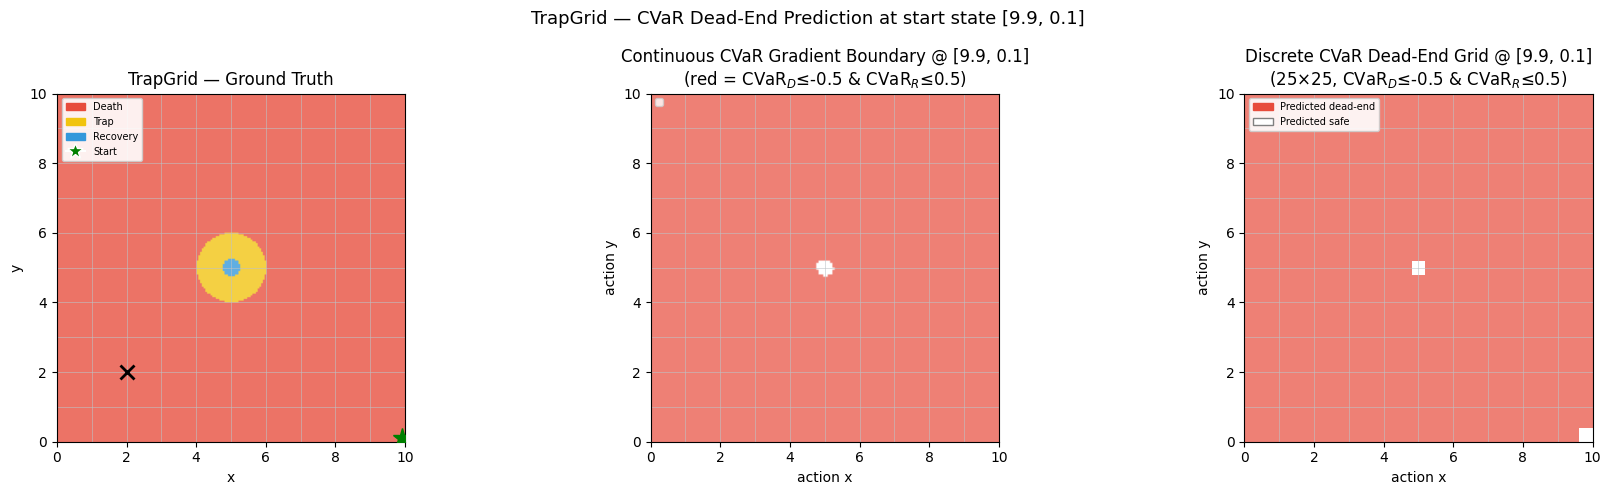

Saved to /home/jay/Uni/SafetyResearch/runs/trapgrid_25bin/trapgrid_cvar_dead_end_boundary.png


In [5]:
if c_qd is not None and c_qr is not None and d_qd is not None and d_qr is not None:
    _nk = max(1, int(ALPHA * N_TAU))

    # ── Continuous: dense background grid ────────────────────────────────────
    _BG_RES = 150
    _bg_pts = np.linspace(0.0, SIZE, _BG_RES, dtype=np.float32)
    _bg_xx, _bg_yy = np.meshgrid(_bg_pts, _bg_pts)
    _bg_actions = np.stack([_bg_xx.ravel(), _bg_yy.ravel()], axis=1)
    _Nbg = len(_bg_actions)
    _bg_states = np.tile(np.array([FIXED_STATE], dtype=np.float32), (_Nbg, 1))

    _net_d = _prep_cont_net(c_qd)
    _net_d.eval()
    _net_r = _prep_cont_net(c_qr)
    _net_r.eval()

    _chunk = 10000
    _cd_flat, _cr_flat = [], []
    for _start in range(0, _Nbg, _chunk):
        _st = torch.from_numpy(_bg_states[_start:_start + _chunk]).to(DEVICE)
        _at = torch.from_numpy(_bg_actions[_start:_start + _chunk]).to(DEVICE)
        with torch.no_grad():
            _qd_out, _ = _net_d.forward(_st, _at, num_tau=N_TAU)
            _qr_out, _ = _net_r.forward(_st, _at, num_tau=N_TAU)
        _cd_flat.append(np.sort(_qd_out.squeeze(-1).cpu().numpy(), axis=1)[:, :_nk].mean(axis=1))
        _cr_flat.append(np.sort(_qr_out.squeeze(-1).cpu().numpy(), axis=1)[:, :_nk].mean(axis=1))

    _cvar_d_bg = np.concatenate(_cd_flat)
    _cvar_r_bg = np.concatenate(_cr_flat)
    _dead_mask  = (_cvar_d_bg <= DELTA_D) & (_cvar_r_bg <= DELTA_R)
    _dead_grid  = _dead_mask.reshape(_BG_RES, _BG_RES)
    print(f'Continuous dead-end fraction: {_dead_mask.mean():.3f}')

    _bg_rgba = np.zeros((_BG_RES, _BG_RES, 4), dtype=np.uint8)
    _bg_rgba[ _dead_grid] = [231,  76,  60, 180]
    _bg_rgba[~_dead_grid] = [255, 255, 255, 220]

    # ── Continuous: gradient boundary tracer ─────────────────────────────────
    def _make_cvar_qfn(network, n_tau=N_TAU, n_keep=_nk, device=DEVICE):
        def q_fn(s, a):
            quantiles, _ = network.forward(s, a, num_tau=n_tau)
            q = quantiles.squeeze(-1)
            q_sorted, _ = torch.sort(q, dim=1)
            return q_sorted[:, :n_keep].mean(dim=1, keepdim=True)
        return q_fn

    _state_t = torch.tensor([FIXED_STATE], dtype=torch.float32)

    print('Running gradient boundary tracer on Q_d...')
    _tracer_d = BoundaryTracer(_net_d, _state_t, threshold=DELTA_D,
                               action_low=0.0, action_high=SIZE,
                               device=DEVICE, q_fn=_make_cvar_qfn(_net_d))
    _comps_d, _ = _tracer_d.run(M=15)
    print(f'  Q_d: {len(_comps_d)} component(s), {_tracer_d.eval_count} evals')

    print('Running gradient boundary tracer on Q_r...')
    _tracer_r = BoundaryTracer(_net_r, _state_t, threshold=DELTA_R,
                               action_low=0.0, action_high=SIZE,
                               device=DEVICE, q_fn=_make_cvar_qfn(_net_r))
    _comps_r, _ = _tracer_r.run(M=15)
    print(f'  Q_r: {len(_comps_r)} component(s), {_tracer_r.eval_count} evals')

    # ── Discrete: dead-end grid ───────────────────────────────────────────────
    _cvar_d_disc = compute_disc_cvar(d_qd)
    _cvar_r_disc = compute_disc_cvar(d_qr)
    _d_dead = (_cvar_d_disc <= DELTA_D) & (_cvar_r_disc <= DELTA_R)
    print(f'Discrete dead-end fraction: {_d_dead.mean():.3f}')

    _disc_rgba = np.zeros((N_BINS, N_BINS, 4), dtype=np.uint8)
    _disc_rgba[ _d_dead] = [231,  76,  60, 180]
    _disc_rgba[~_d_dead] = [255, 255, 255, 220]

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: ground truth
    plot_ground_truth(ax=axes[0], resolution=200)

    # Plot 2: continuous gradient boundary
    axes[1].imshow(_bg_rgba, origin='lower',
                   extent=[0.0, SIZE, 0.0, SIZE], aspect='equal')
    for i in range(11):
        axes[1].axhline(i, color='#bdc3c7', lw=0.4, zorder=2)
        axes[1].axvline(i, color='#bdc3c7', lw=0.4, zorder=2)
    _plotted_d = _plotted_r = False
    for _comp in _comps_d:
        if len(_comp) < 2:
            continue
        _pa = np.array(_comp)
        axes[1].plot(_pa[:, 0], _pa[:, 1], color='black', lw=1.5,
                     label='CVaR$_D$ boundary' if not _plotted_d else '_nolegend_')
        _plotted_d = True
    for _comp in _comps_r:
        if len(_comp) < 2:
            continue
        _pa = np.array(_comp)
        axes[1].plot(_pa[:, 0], _pa[:, 1], color='blue', lw=1.5, linestyle='--',
                     label='CVaR$_R$ boundary' if not _plotted_r else '_nolegend_')
        _plotted_r = True
    axes[1].legend(fontsize=7, loc='upper left')
    axes[1].set_xlim(0, SIZE); axes[1].set_ylim(0, SIZE)
    axes[1].set_xlabel('action x'); axes[1].set_ylabel('action y')
    axes[1].set_title(f'Continuous CVaR Gradient Boundary @ {FIXED_STATE}\n'
                      f'(red = CVaR$_D$≤{DELTA_D} & CVaR$_R$≤{DELTA_R})')

    # Plot 3: discrete grid
    disc_axs = np.linspace(0.0, SIZE, N_BINS, dtype=np.float32)
    axes[2].imshow(np.transpose(_disc_rgba, (1, 0, 2)), origin='lower',
                   extent=[0.0, SIZE, 0.0, SIZE], aspect='equal', interpolation='nearest')
    for i in range(11):
        axes[2].axhline(i, color='#bdc3c7', lw=0.4, zorder=2)
        axes[2].axvline(i, color='#bdc3c7', lw=0.4, zorder=2)
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label=f'Predicted dead-end'),
        mpatches.Patch(color='white',   label='Predicted safe', ec='grey'),
    ]
    axes[2].legend(handles=legend_patches, fontsize=7, framealpha=0.9, loc='upper left')
    axes[2].set_xlim(0, SIZE); axes[2].set_ylim(0, SIZE)
    axes[2].set_xlabel('action x'); axes[2].set_ylabel('action y')
    axes[2].set_title(f'Discrete CVaR Dead-End Grid @ {FIXED_STATE}\n'
                      f'({N_BINS}×{N_BINS}, CVaR$_D$≤{DELTA_D} & CVaR$_R$≤{DELTA_R})')

    fig.suptitle(f'TrapGrid — CVaR Dead-End Prediction at start state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'trapgrid_cvar_dead_end_boundary.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — agents not loaded.')

## 5. Confusion Matrix Helpers

In [6]:
N_SAMPLE_ACTIONS = 100000   # actions sampled uniformly from [0, SIZE]²
EVAL_STATE       = FIXED_STATE   # [9.9, 0.1]
CHUNK_SIZE       = 4096


def plot_confusion_matrix(cm, title='Confusion Matrix', ax=None):
    """Plot a 2×2 confusion matrix [[TN, FP], [FN, TP]]."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 3.8))
    else:
        fig = ax.figure
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    labels = ['Not Dead-End', 'Dead-End']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(title, fontsize=9)
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > thresh else 'black')
    return fig, ax


def print_metrics(TP, TN, FP, FN, label=''):
    precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
    recall    = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else float('nan'))
    acc       = (TP + TN) / (TP + TN + FP + FN)
    print(f'\n── {label} ──')
    print(f'  TP={TP:5d}  TN={TN:5d}  FP={FP:5d}  FN={FN:5d}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')


def _cvar_batch(network, states_np, actions_np, n_tau, n_keep, device, chunk=CHUNK_SIZE):
    """Chunked forward pass → CVaR per (state, action) pair."""
    out = []
    for s in range(0, len(states_np), chunk):
        s_t = torch.from_numpy(states_np[s:s + chunk]).to(device)
        a_t = torch.from_numpy(actions_np[s:s + chunk]).to(device)
        with torch.no_grad():
            q, _ = network.forward(s_t, a_t, num_tau=n_tau)
        qs = np.sort(q.squeeze(-1).cpu().numpy(), axis=1)
        out.append(qs[:, :n_keep].mean(axis=1))
    return np.concatenate(out)


def evaluate_cont_action_space(qd_agent, qr_agent, state=EVAL_STATE,
                               n_actions=N_SAMPLE_ACTIONS, seed=42):
    """Sample n_actions uniformly from [0, SIZE]² and evaluate CVaR at fixed state.

    Ground truth: classify_point(ax, ay) in ('death', 'trap')  — action IS next state.
    Prediction  : CVaR_D ≤ DELTA_D AND CVaR_R ≤ DELTA_R
    """
    rng     = np.random.default_rng(seed)
    actions = rng.uniform(0.0, SIZE, size=(n_actions, 2)).astype(np.float32)
    states  = np.tile(np.array([state], dtype=np.float32), (n_actions, 1))

    gt = np.array([classify_point(a[0], a[1]) in ('death', 'trap') for a in actions], dtype=bool)

    n_keep = max(1, int(ALPHA * N_TAU))
    net_d  = _prep_cont_net(qd_agent); net_d.eval()
    net_r  = _prep_cont_net(qr_agent); net_r.eval()

    cvar_d = _cvar_batch(net_d, states, actions, N_TAU, n_keep, DEVICE)
    cvar_r = _cvar_batch(net_r, states, actions, N_TAU, n_keep, DEVICE)
    pred   = (cvar_d <= DELTA_D) & (cvar_r <= DELTA_R)
    return gt, pred, actions


def evaluate_disc_action_space(qd_agent, qr_agent, state=EVAL_STATE,
                               n_actions=N_SAMPLE_ACTIONS, seed=42):
    """Sample n_actions uniformly and classify via nearest discrete bin.

    GT is evaluated at the actual sampled point; prediction uses the nearest bin's CVaR.
    """
    rng     = np.random.default_rng(seed)
    actions = rng.uniform(0.0, SIZE, size=(n_actions, 2)).astype(np.float32)

    gt = np.array([classify_point(a[0], a[1]) in ('death', 'trap') for a in actions], dtype=bool)

    # Precompute CVaR grid once over all 625 bins
    cvar_d_grid = compute_disc_cvar(qd_agent, state)  # (N_BINS, N_BINS)
    cvar_r_grid = compute_disc_cvar(qr_agent, state)

    # Map each sampled action to its nearest bin index
    step = SIZE / (N_BINS - 1)
    xi   = np.clip(np.rint(actions[:, 0] / step).astype(int), 0, N_BINS - 1)
    yi   = np.clip(np.rint(actions[:, 1] / step).astype(int), 0, N_BINS - 1)

    pred = (cvar_d_grid[xi, yi] <= DELTA_D) & (cvar_r_grid[xi, yi] <= DELTA_R)
    return gt, pred, actions


print('Confusion matrix helpers defined.')

Confusion matrix helpers defined.


Evaluating 100000 uniform actions (discrete) at state [9.9, 0.1] …


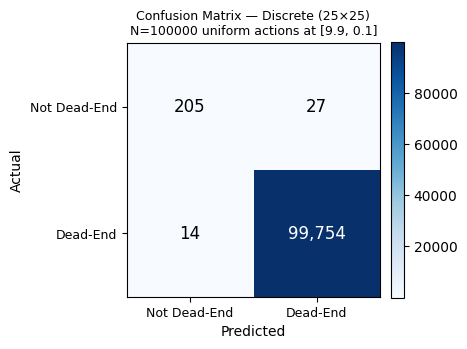


── Discrete 25-bin ──
  TP=99754  TN=  205  FP=   27  FN=   14
  Precision : 0.9997
  Recall    : 0.9999
  F1 Score  : 0.9998
  Accuracy  : 0.9996
Saved to /home/jay/Uni/SafetyResearch/runs/trapgrid_25bin/trapgrid_cm_discrete.png


In [7]:
## 6. Confusion Matrix — Discrete (25-bin IQN) at Start State

if d_qd is not None and d_qr is not None:
    print(f'Evaluating {N_SAMPLE_ACTIONS} uniform actions (discrete) at state {EVAL_STATE} …')
    gt_d, pred_d, actions_d = evaluate_disc_action_space(d_qd, d_qr)

    TP = int(( gt_d &  pred_d).sum())
    TN = int((~gt_d & ~pred_d).sum())
    FP = int((~gt_d &  pred_d).sum())
    FN = int(( gt_d & ~pred_d).sum())
    cm_disc = np.array([[TN, FP], [FN, TP]])

    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    plot_confusion_matrix(
        cm_disc,
        title=(f'Confusion Matrix — Discrete ({N_BINS}×{N_BINS})\n'
               f'N={N_SAMPLE_ACTIONS} uniform actions at {EVAL_STATE}'),
        ax=ax,
    )
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'trapgrid_cm_discrete.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print_metrics(TP, TN, FP, FN, label='Discrete 25-bin')
    print('Saved to', out_path)
else:
    print('Skipped — discrete agents not loaded.')

Evaluating 100000 uniform actions (continuous) at state [9.9, 0.1] …


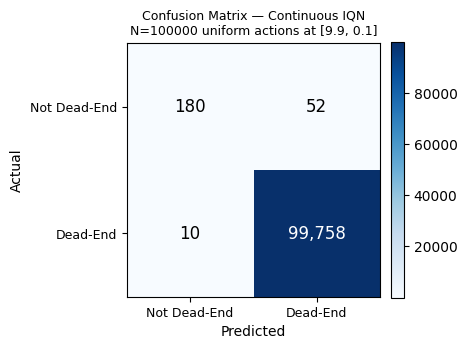


── Continuous IQN ──
  TP=99758  TN=  180  FP=   52  FN=   10
  Precision : 0.9995
  Recall    : 0.9999
  F1 Score  : 0.9997
  Accuracy  : 0.9994
Saved to /home/jay/Uni/SafetyResearch/runs/trapgrid_cont/trapgrid_cm_continuous.png


In [8]:
## 7. Confusion Matrix — Continuous IQN at Start State

if c_qd is not None and c_qr is not None:
    print(f'Evaluating {N_SAMPLE_ACTIONS} uniform actions (continuous) at state {EVAL_STATE} …')
    gt_c, pred_c, actions_c = evaluate_cont_action_space(c_qd, c_qr)

    TPc = int(( gt_c &  pred_c).sum())
    TNc = int((~gt_c & ~pred_c).sum())
    FPc = int((~gt_c &  pred_c).sum())
    FNc = int(( gt_c & ~pred_c).sum())
    cm_cont = np.array([[TNc, FPc], [FNc, TPc]])

    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    plot_confusion_matrix(
        cm_cont,
        title=(f'Confusion Matrix — Continuous IQN\n'
               f'N={N_SAMPLE_ACTIONS} uniform actions at {EVAL_STATE}'),
        ax=ax,
    )
    plt.tight_layout()
    out_path = os.path.join(CONT_RUN_DIR, 'trapgrid_cm_continuous.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print_metrics(TPc, TNc, FPc, FNc, label='Continuous IQN')
    print('Saved to', out_path)
else:
    print('Skipped — continuous agents not loaded.')